In [1]:
import numpy as np
import math
import configparser
import scipy
from scipy.constants import h       # Planck constant
from scipy.constants import hbar    # reduced Planck constant
from scipy.constants import k       # Boltzmann constant
from scipy.constants import N_A     # Avogadro number
from scipy.constants import e       # elementary charge
from scipy.constants import m_e     # mass of electron
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.optimize import fsolve
from scipy import integrate
from scipy.integrate import simpson as simps
from scipy.integrate import trapezoid as trapz
import scipy.stats as stats
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import ticker
from matplotlib.ticker import LinearLocator, FixedLocator, MaxNLocator, MultipleLocator, EngFormatter, AutoMinorLocator
import csv
import time
import random
import pandas as pd

### Analytical Model for computing the two-channel based lattice thermal conductivity

Average SoS =  1601.3829497943993
Debye temperature ΘD =  171.32118539999976

Fitted Parameters:
Ioffe-Regel Frequency = 0.91 THz
C1 = 11.801 ± 0.281  × 10⁻¹⁶
A  = 0.015 ± 0.002
C3 = 15.431 ± 1.835  × 10⁻⁴⁰
P  = 0.387 ± 0.007


/tmp/ipykernel_214098/1943083758.py:8: RuntimeWarning: overflow encountered in exp
  return x**2 * np.exp(x) / (np.exp(x) - 1)**2
/tmp/ipykernel_214098/1943083758.py:8: RuntimeWarning: invalid value encountered in divide
  return x**2 * np.exp(x) / (np.exp(x) - 1)**2
/tmp/ipykernel_214098/1943083758.py:8: RuntimeWarning: overflow encountered in multiply
  return x**2 * np.exp(x) / (np.exp(x) - 1)**2
/tmp/ipykernel_214098/1943083758.py:8: RuntimeWarning: overflow encountered in square
  return x**2 * np.exp(x) / (np.exp(x) - 1)**2


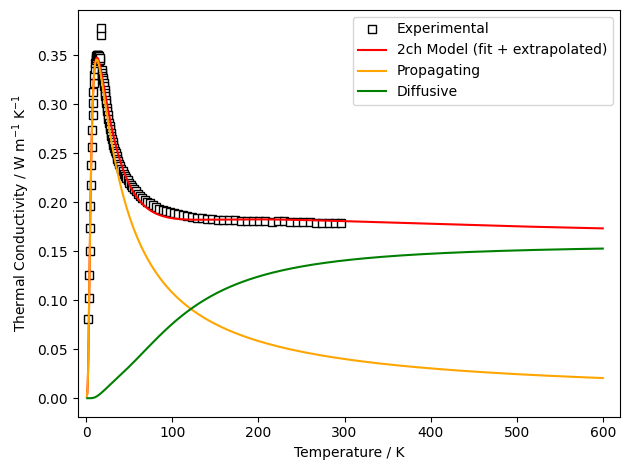

In [3]:
# --- Functions ---

def HarmonicVs(vTrans, vLong):
    return (3 * (vLong**-3 + 2 * vTrans**-3) ** -1) ** (1/3)

def C_omega(angular_freq, Temp):
    x = (hbar * angular_freq) / (k * (Temp + 1e-10))
    return x**2 * np.exp(x) / (np.exp(x) - 1)**2

def omega_IR(n, vs, N):
    return (6 * n * np.pi**2)**(1/3) * vs * N**(-1/3)

def kappa_2ch(Temp, C1, A, C3, P):
    w_IR = omega_IR(n, vs, N)
    Prop_vals = np.where(omega < w_IR)
    Diff_vals = np.where(omega >= w_IR)
    kappa_tot = []

    for T in Temp:
        inverse_tau = (C1 * 1e-16 * omega[Prop_vals]**2 * T) + \
                      (A * omega[Prop_vals]) + \
                      (C3 * 1e-40 * omega[Prop_vals]**4)
        kappa_pr_omega = DOS[Prop_vals] * C_omega(omega[Prop_vals], T) * vs**2 / inverse_tau
        kappa_diff_omega = DOS[Diff_vals] * C_omega(omega[Diff_vals], T) * P * omega[Diff_vals]
        kappa_pr = (1 / 3) * (3 * n * k) * trapz(kappa_pr_omega, omega[Prop_vals])
        kappa_diff = (1 / np.pi) * n**(1/3) * k * trapz(kappa_diff_omega, omega[Diff_vals])
        kappa_tot.append(kappa_pr + kappa_diff)

    return kappa_tot

def both_kappas(Temp, C1, A, C3, P):
    omega_IR_val = omega_IR(n, vs, N)
    Prop_vals = np.where(omega < omega_IR_val)
    Diff_vals = np.where(omega >= omega_IR_val)

    kappa_tot, prop, diff = [], [], []
    for T in Temp:
        inverse_tau = (C1 * 1e-16 * omega[Prop_vals]**2 * T) + \
                      (A * omega[Prop_vals]) + \
                      (C3 * 1e-40 * omega[Prop_vals]**4)
        kappa_pr_omega = DOS[Prop_vals] * C_omega(omega[Prop_vals], T) * vs**2 / inverse_tau
        kappa_diff_omega = DOS[Diff_vals] * C_omega(omega[Diff_vals], T) * P * omega[Diff_vals]
        kappa_pr = (1 / 3) * (3 * n * k) * trapz(kappa_pr_omega, omega[Prop_vals])
        kappa_diff = (1 / np.pi) * n**(1/3) * k * trapz(kappa_diff_omega, omega[Diff_vals])
        prop.append(kappa_pr)
        diff.append(kappa_diff)
        kappa_tot.append(kappa_pr + kappa_diff)

    return prop, diff

# --- Load DOS ---
dat = np.loadtxt('total_dos.dat')
freq = dat[:, 0]  # THz
DOS = dat[:, 1]
omega = 2 * np.pi * freq * 1e12  # Hz
DOS /= trapz(DOS, omega)  # Normalize

# --- Material properties ---
vl = 2871  # m/s
vt = 1427  # m/s
vs = HarmonicVs(vt, vl)
N = 60  # atoms per unit cell
n = 4.64e28  # atom density m⁻³
print("Average SoS = ", vs)
print("Debye temperature ΘD = ", (hbar / k) * (6 * np.pi**2 * n)**(1/3) * vs)

# --- Load experimental data ---
data = pd.read_csv('sample_temp_conductivity.csv')
T = data['Tem'].values
kappa_exp = data['Conductivity'].values

# --- Fit only up to 300 K ---
mask_fit = T <= 300
T_fit = T[mask_fit]
kappa_fit = kappa_exp[mask_fit]

val, var = curve_fit(kappa_2ch, T_fit, kappa_fit, p0=[1.60, 0.02, 0.5, 1],
                     bounds=((0, 0.015, 0, 0), (np.inf, 0.1, np.inf, 1)))

stdev = np.sqrt(np.diag(var))

# --- Print fit results ---
print('\nFitted Parameters:')
print(f'Ioffe-Regel Frequency = {omega_IR(n, vs, N) * 1e-12 / (2 * np.pi):.2f} THz')
print(f'C1 = {val[0]:.3f} ± {stdev[0]:.3f}  × 10⁻¹⁶')
print(f'A  = {val[1]:.3f} ± {stdev[1]:.3f}')
print(f'C3 = {val[2]:.3f} ± {stdev[2]:.3f}  × 10⁻⁴⁰')
print(f'P  = {val[3]:.3f} ± {stdev[3]:.3f}')

# --- Predict up to 600 K ---
T_predict = np.linspace(0, 600, 1000)
kappa_model = kappa_2ch(T_predict, *val)
kappa_pr, kappa_diff = both_kappas(T_predict, *val)

# --- Plot ---
plt.figure()
plt.plot(T, kappa_exp, 'ks', markerfacecolor='w', label='Experimental')
plt.plot(T_predict, kappa_model, 'r-', label='2ch Model (fit + extrapolated)')
plt.plot(T_predict, kappa_pr, '-', color='orange', label='Propagating')
plt.plot(T_predict, kappa_diff, '-', color='green', label='Diffusive')
plt.xlabel('Temperature / K')
plt.ylabel('Thermal Conductivity / W m$^{-1}$ K$^{-1}$')
plt.legend()
plt.xlim([-10, 620])
plt.tight_layout()
plt.savefig('2ch_model_extrapolated_to_600K.tif', dpi=300)
plt.show()

## Phonon-channel 

In [4]:
C1 =  11.805
A  =  0.015
C3 =  15.423
P  =  0.387
prop_total = []
omega_IR_val = omega_IR(n, vs, N)
Prop_vals = np.where(omega < omega_IR_val)

Temp= list(range(2, 200, 2))
for T in Temp:
    inverse_tau = (C1 * 1e-16 * omega[Prop_vals] ** 2 * T) + (A * omega[Prop_vals]) + (C3 * 1e-40 * omega[Prop_vals] ** 4)
    kappa_pr_omega = DOS[Prop_vals] * C_omega(omega[Prop_vals], T) * vs ** 2 * inverse_tau ** (-1)    
    kappa_pr = (1/3) * (3 * n * k) * trapz(kappa_pr_omega, omega[Prop_vals])
    prop_total.append(kappa_pr)

## Phonon-channel subtracting Point-defect

In [5]:
prop_C1_A = []
Temp= list(range(2, 200, 2))
for T in Temp:
    inverse_tau = (C1 * 1e-16 * omega[Prop_vals] ** 2 * T) + (A * omega[Prop_vals])
    kappa_pr_omega = DOS[Prop_vals] * C_omega(omega[Prop_vals], T) * vs ** 2 * inverse_tau ** (-1)    
    kappa_pr = (1/3) * (3 * n * k) * trapz(kappa_pr_omega, omega[Prop_vals])
    prop_C1_A.append(kappa_pr)

## Phonon-channel subtracting Point-defect and boundary scattering

In [6]:
prop_C1 = []
Temp= list(range(2, 200, 2))
for T in Temp:
    inverse_tau = (C1 * 1e-16 * omega[Prop_vals] ** 2 * T)
    kappa_pr_omega = DOS[Prop_vals] * C_omega(omega[Prop_vals], T) * vs ** 2 * inverse_tau ** (-1)    
    kappa_pr = (1/3) * (3 * n * k) * trapz(kappa_pr_omega, omega[Prop_vals])
    prop_C1.append(kappa_pr)

## Phonon-channel (comparison plot) 

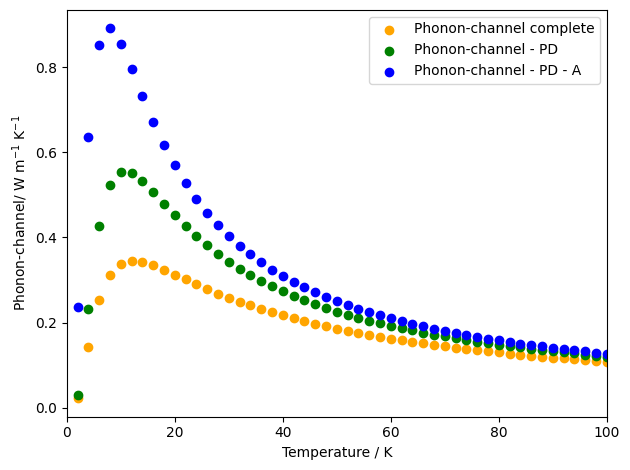

In [7]:
plt.scatter(Temp, prop_total, color='orange', label='Phonon-channel complete')
plt.scatter(Temp, prop_C1_A, color='green',  label='Phonon-channel - PD')
plt.scatter(Temp, prop_C1, color='blue',  label='Phonon-channel - PD - A')
plt.xlim(0,100)
plt.xlabel('Temperature / K')
plt.ylabel('Phonon-channel/ W m$^{-1}$ K$^{-1}$')
plt.legend()
plt.tight_layout()
plt.savefig('Comparison_phonon_channel', dpi=300)
plt.show()